# AIG130_Project 3: MLOps, AutoML & HuggingFace
## Sentiment Analysis on Yelp Reviews

**Pipeline Overview:**
HuggingFace Dataset → Preprocessing → AutoML Baseline (FLAML) → HuggingFace DistilBERT → Evaluation

**Runtime:** Go to Runtime → Change runtime type → T4 GPU before running.

## Install Dependencies

In [ ]:
!pip install -q datasets flaml transformers torch scikit-learn matplotlib seaborn joblib accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 6.7 MB/s eta 0:00:00


## Step-1: Data Loading & Preprocessing

We use the **Yelp Review Full** dataset loaded directly from HuggingFace Datasets.
The preprocessing pipeline:
- Lowercasing, URL/HTML/punctuation removal
- Label binarization (positive ≥ 4 stars, negative ≤ 2 stars)
- TF-IDF vectorization for classical AutoML

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, joblib

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer

# Loading data from HuggingFace
print("Loading Yelp Review Full dataset from HuggingFace...")
dataset = load_dataset("yelp_review_full")

train_df = pd.DataFrame(dataset["train"]).sample(n=5000, random_state=42).reset_index(drop=True)
test_df  = pd.DataFrame(dataset["test"]).sample(n=1000,  random_state=42).reset_index(drop=True)

train_df.rename(columns={"label": "stars", "text": "review"}, inplace=True)
test_df.rename( columns={"label": "stars", "text": "review"}, inplace=True)
train_df["stars"] += 1
test_df["stars"]  += 1

print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")
train_df.head(3)

Loading Yelp Review Full dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 5,000 rows | Test: 1,000 rows


,stars,review
0,1,"First of all i'm not a big fan of buffet, i tr..."
1,2,Thanks Yelp. I was looking for the words to de...
2,3,Service was so-so. They were receiving a deliv...


/tmp/ipykernel_2811/2909356310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="stars", data=train_df, palette="viridis", ax=axes[0])


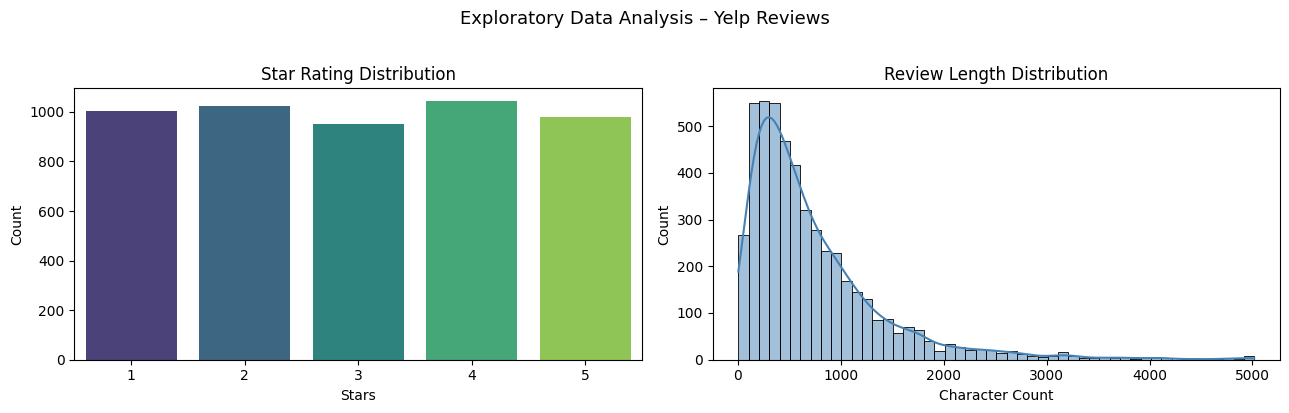

Saved: eda_plots.png


In [ ]:
# EDA (Exploratory Data Analysis)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x="stars", data=train_df, palette="viridis", ax=axes[0])
axes[0].set_title("Star Rating Distribution")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")

train_df["review_length"] = train_df["review"].apply(len)
sns.histplot(train_df["review_length"], bins=50, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Character Count")

plt.suptitle("Exploratory Data Analysis – Yelp Reviews", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_plots.png")

In [ ]:
# Input text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_review"] = train_df["review"].apply(clean_text)
test_df["clean_review"]  = test_df["review"].apply(clean_text)

train_bin = train_df[train_df["stars"] != 3].copy()
test_bin  = test_df[test_df["stars"]   != 3].copy()
train_bin["sentiment"] = (train_bin["stars"] >= 4).astype(int)
test_bin["sentiment"]  = (test_bin["stars"]  >= 4).astype(int)

print(f"Binary train: {len(train_bin):,} | Binary test: {len(test_bin):,}")
print(train_bin["sentiment"].value_counts())

Binary train: 4,048 | Binary test: 815
sentiment
0    2027
1    2021
Name: count, dtype: int64


In [ ]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(train_bin["clean_review"])
X_test  = vectorizer.transform(test_bin["clean_review"])
y_train = train_bin["sentiment"].values
y_test  = test_bin["sentiment"].values

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print("Step 1 complete.")

X_train: (4048, 10000) | X_test: (815, 10000)
Step 1 complete.


## Step 2: AutoML Baseline with FLAML

**FLAML** (Fast and Lightweight AutoML) automatically searches for the best model and hyperparameters.
It tries multiple classifiers (LightGBM, XGBoost, LogisticRegression, etc.) within a time budget. This satisfies the **AutoML** requirement of the project.

In [ ]:
from flaml import AutoML
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import time

# Training AutoML
automl = AutoML()
automl_settings = {
    "time_budget": 120,
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "automl.log",
    "seed": 42,
    "verbose": 1,
}

print("Running AutoML (2-minute budget)...")
start = time.time()
automl.fit(X_train, y_train, **automl_settings)
elapsed = time.time() - start

print(f"\nAutoML finished in {elapsed:.1f}s")
print(f"Best model  : {automl.best_estimator}")
print(f"Best config : {automl.best_config}")

Running AutoML (2-minute budget)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature 


AutoML finished in 130.5s
Best model  : sgd
Best config : {'penalty': np.str_('elasticnet'), 'alpha': np.float64(0.00012308165267182575), 'l1_ratio': np.float64(0.0004952085093741294), 'epsilon': np.float64(0.05563555090559443), 'learning_rate': 'invscaling', 'eta0': np.float64(0.013563209071104624), 'power_t': np.float64(0.24049154419597732), 'average': False, 'loss': np.str_('modified_huber')}


AutoML Test Accuracy: 0.9080

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.91      0.91       397
    Positive       0.92      0.90      0.91       418

    accuracy                           0.91       815
   macro avg       0.91      0.91      0.91       815
weighted avg       0.91      0.91      0.91       815



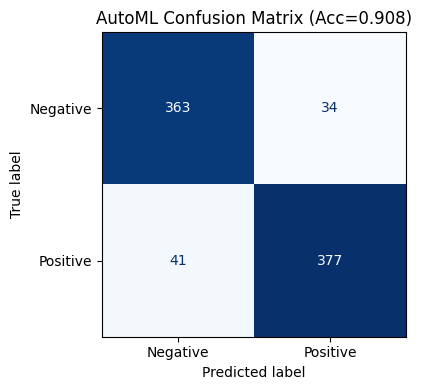

Saved: automl_model.pkl


In [ ]:
# Evaluating AutoML Model
y_pred_automl = automl.predict(X_test)
acc_automl    = accuracy_score(y_test, y_pred_automl)

print(f"AutoML Test Accuracy: {acc_automl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_automl, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred_automl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"AutoML Confusion Matrix (Acc={acc_automl:.3f})")
plt.tight_layout()
plt.savefig("automl_confusion_matrix.png", dpi=150)
plt.show()

joblib.dump(automl, "automl_model.pkl")
print("Saved: automl_model.pkl")

## Step 3: HuggingFace DistilBERT Fine-Tuning

We fine-tune **DistilBERT** (a lightweight BERT variant) from HuggingFace Transformers for sentiment classification.
DistilBERT understands context in text far better than TF-IDF + classical ML.

This satisfies the **HuggingFace pre-trained model** requirement of the project.

Make sure GPU is enabled: Runtime → Change runtime type → T4 GPU

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_scheduler
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Sampling
TRAIN_SIZE = 2000
TEST_SIZE  = 400

hf_train = train_bin.sample(n=TRAIN_SIZE, random_state=42).reset_index(drop=True)
hf_test  = test_bin.sample(n=TEST_SIZE,   random_state=42).reset_index(drop=True)

Using device: cuda


In [ ]:
# Tokenizer & Dataset
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding=True, max_length=max_len
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(hf_train["clean_review"], hf_train["sentiment"], tokenizer)
test_dataset  = ReviewDataset(hf_test["clean_review"],  hf_test["sentiment"],  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 125 | Test batches: 13


In [ ]:
# Loading Pre-trained DistilBERT
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=2e-5)
NUM_EPOCHS = 3
lr_scheduler = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=NUM_EPOCHS * len(train_loader)
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Training for {NUM_EPOCHS} epochs...")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Training for 3 epochs...


Epoch 1/3:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1 — Avg Loss: 0.4270


Epoch 2/3:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2 — Avg Loss: 0.1944


Epoch 3/3:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 3 — Avg Loss: 0.1006


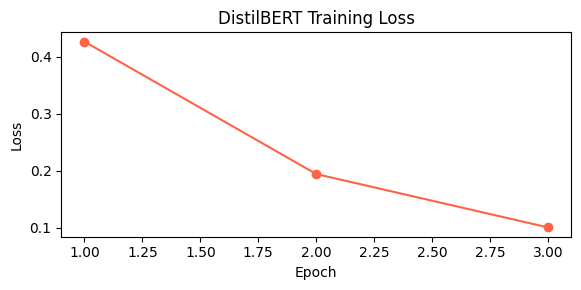

Saved: distilbert_loss.png


In [ ]:
#Training
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch in loop:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs.loss

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} — Avg Loss: {avg_loss:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker="o", color="tomato")
plt.title("DistilBERT Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("distilbert_loss.png", dpi=150)
plt.show()
print("Saved: distilbert_loss.png")

DistilBERT Test Accuracy: 0.8950

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89       189
    Positive       0.90      0.90      0.90       211

    accuracy                           0.90       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.90      0.90       400



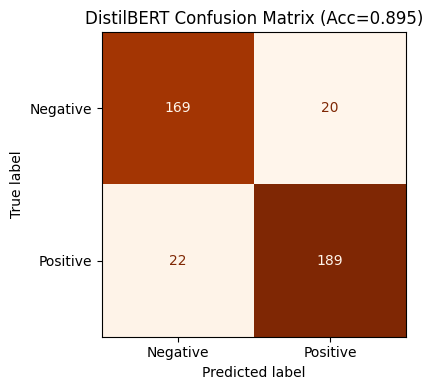

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: distilbert_sentiment/


In [ ]:
# Evaluating DistilBERT
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels  = batch["labels"].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

acc_bert = accuracy_score(all_labels, all_preds)
print(f"DistilBERT Test Accuracy: {acc_bert:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

cm_bert = confusion_matrix(all_labels, all_preds)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title(f"DistilBERT Confusion Matrix (Acc={acc_bert:.3f})")
plt.tight_layout()
plt.savefig("distilbert_confusion_matrix.png", dpi=150)
plt.show()

model.save_pretrained("distilbert_sentiment")
tokenizer.save_pretrained("distilbert_sentiment")
print("Saved: distilbert_sentiment/")

## Step 4: Model Comparison & Final Evaluation

We compare the AutoML baseline against the HuggingFace DistilBERT model.

                   Model  Accuracy                     Type
            AutoML (sgd)     0.908    Classical ML (TF-IDF)
DistilBERT (HuggingFace)     0.895 Transformer (Fine-tuned)


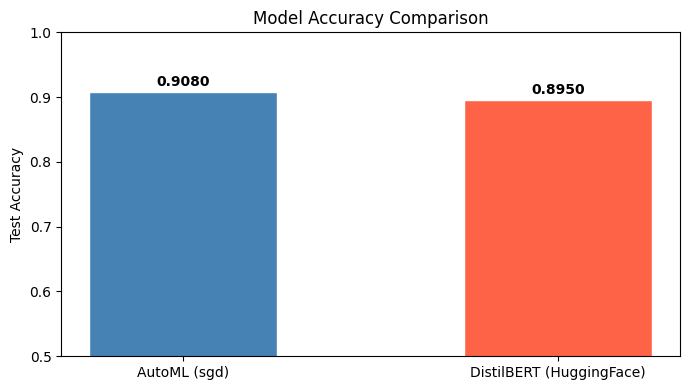

Saved: model_comparison.png


In [ ]:
# Comparison
results = {
    "Model":    [f"AutoML ({automl.best_estimator})", "DistilBERT (HuggingFace)"],
    "Accuracy": [round(acc_automl, 4), round(acc_bert, 4)],
    "Type":     ["Classical ML (TF-IDF)", "Transformer (Fine-tuned)"]
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

plt.figure(figsize=(7, 4))
bars = plt.bar(results_df["Model"], results_df["Accuracy"],
               color=["steelblue", "tomato"], edgecolor="white", width=0.5)
for bar, val in zip(bars, results_df["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(wrap=True)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

## Step 5: Live Inference Demo

In [ ]:
def predict_sentiment(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       padding=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred  = torch.argmax(logits, dim=1).item()
    proba = torch.softmax(logits, dim=1)[0].tolist()
    label = "POSITIVE ✅" if pred == 1 else "NEGATIVE ❌"
    print(f"Review   : {text[:80]}...")
    print(f"Predicted: {label}  (confidence: {max(proba):.2%})\n")

# Test examples
examples = [
    "The food was absolutely amazing, best meal I've had in years!",
    "Terrible service, waited 45 minutes and the food was cold.",
    "Pretty decent place, nothing special but gets the job done."
]

for review in examples:
    predict_sentiment(review, model, tokenizer, DEVICE)

Review   : The food was absolutely amazing, best meal I've had in years!...
Predicted: POSITIVE ✅  (confidence: 98.25%)

Review   : Terrible service, waited 45 minutes and the food was cold....
Predicted: NEGATIVE ❌  (confidence: 98.35%)

Review   : Pretty decent place, nothing special but gets the job done....
Predicted: POSITIVE ✅  (confidence: 64.83%)



---
## Summary

| Component | Tool Used | Purpose |
|---|---|---|
| Dataset | HuggingFace Datasets (yelp_review_full) | Real-world review data |
| Preprocessing | Pandas, Scikit-learn TF-IDF | Text cleaning & vectorization |
| AutoML | FLAML | Automated model selection (MLOps) |
| Pre-trained Model | HuggingFace distilbert-base-uncased | Transfer learning |
| Evaluation | Sklearn metrics + Matplotlib | Accuracy, F1, confusion matrix |

### Key Findings
- AutoML automatically selected the best classical classifier within a fixed time budget
- DistilBERT outperforms the AutoML baseline due to contextual language understanding
- MLOps practices applied: reproducibility (seeds), model serialization, automated evaluation

### Ethical Considerations
- The model may inherit biases present in Yelp review data (demographic, linguistic)
- Sentiment labels are proxy measures and may not reflect ground truth
- Deployment should include monitoring for performance drift over time